<a href="https://colab.research.google.com/github/soonyz06/Stat_Arb/blob/main/Stat_Arb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [365]:
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import random
import scipy.stats as stats

# Loading Data

Cleaning

In [347]:
all_symbols = {"SPY": ["VFVA", "VFMO", "VFQY"],
           "Semi": ["NVDA", "TSM", "AVGO", "AMD", "ASML", "AMAT", "MU", "TXN", "KLAC", "LRCX", "ADI", "INTC", "QCOM", "MRVL"],
           "Memory": ["005930.KS", "MU", "000660.KS", "STX", "WDC"]}

lf = pl.scan_parquet("data.parquet")
lf.tail(5).collect()

date,symbol,open,high,low,close,adjclose,volume
date,str,f64,f64,f64,f64,f64,f64
2017-03-08,"""SPY""",237.339996,237.639999,236.399994,236.559998,203.716492,7.81688e7
2007-11-02,"""WDC""",20.907028,22.260015,20.861677,21.851852,17.462666,1.7163014e7
2012-02-22,"""MU""",8.21,8.24,8.01,8.04,7.840103,1.93817e7
2005-04-11,"""ASML""",24.209415,24.224026,23.756495,23.946428,15.402525,826398.0
1976-04-07,"""TXN""",2.669271,2.679688,2.627604,2.627604,1.100116,1.5264e6


In [348]:
display(lf.describe())
symbols = lf.select("symbol").unique().collect().to_series().to_list()
print(len(symbols), "symbols: ", symbols)

statistic,date,symbol,open,high,low,close,adjclose,volume
str,str,str,f64,f64,f64,f64,f64,f64
"""count""","""184779""","""184779""",184779.0,184779.0,184779.0,184778.0,184778.0,184779.0
"""null_count""","""0""","""0""",0.0,0.0,0.0,1.0,1.0,0.0
"""mean""","""2007-09-20 11:45:44.552140""",null,4966.091887,5070.344391,4865.966723,4964.73808,3744.79756,3.9425e7
"""std""",null,null,48528.191658,50129.050608,46976.56463,48518.671613,46422.381306,1.3853e8
"""min""","""1972-06-01""","""000660.KS""",0.0,0.0,0.0,0.034115,-246206.015625,0.0
"""25%""","""1998-08-24""",null,4.393424,4.487906,4.309,4.393424,3.022521,2.6016e6
"""50%""","""2009-05-05""",null,21.4,21.78125,21.022299,21.389999,15.609244,8.9488e6
"""75%""","""2018-11-13""",null,78.769997,79.5,78.0,78.720001,66.749855,2.37216e7
"""max""","""2026-07-21""","""WDC""",2.898e6,2.987e6,2.749e6,2.919e6,2.919e6,9.2309e9


27 symbols:  ['MRVL', '285A.T', 'STX', '000660.KS', 'WDC', 'QCOM', 'TSM', 'NVDA', '005930.KS', 'MU', 'TXN', 'FGXXX', 'LRCX', 'VFQY', 'ADI', 'ASML', 'VFLQ', 'AMD', 'AVGO', 'INTC', 'SPY', 'AMAT', 'VFVA', 'MVRL', 'SNDK', 'VFMO', 'KLAC']


In [349]:
print(lf.filter(pl.any_horizontal(pl.all().is_null())).collect())
lf = lf.drop_nulls()

shape: (1, 8)
┌────────────┬────────┬──────┬──────┬─────┬───────┬──────────┬────────┐
│ date       ┆ symbol ┆ open ┆ high ┆ low ┆ close ┆ adjclose ┆ volume │
│ ---        ┆ ---    ┆ ---  ┆ ---  ┆ --- ┆ ---   ┆ ---      ┆ ---    │
│ date       ┆ str    ┆ f64  ┆ f64  ┆ f64 ┆ f64   ┆ f64      ┆ f64    │
╞════════════╪════════╪══════╪══════╪═════╪═══════╪══════════╪════════╡
│ 2026-07-20 ┆ FGXXX  ┆ 0.0  ┆ 0.0  ┆ 0.0 ┆ null  ┆ null     ┆ 0.0    │
└────────────┴────────┴──────┴──────┴─────┴───────┴──────────┴────────┘


In [350]:
symbols = [s for v in all_symbols.values() for s in v] + ["SPY"]
lf = lf.filter(pl.col("symbol").is_in(symbols))

dates = lf.group_by("symbol").agg([
    pl.col("date").min().alias("min_date"),
    pl.col("date").max().alias("max_date"),
    pl.len().alias("rows")
]).collect()

display(dates.head(3))
print("\n")
display(dates.filter(pl.col("min_date") == pl.col("min_date").max()).head(3))
print("\n")
display(dates.filter(pl.col("max_date") == pl.col("max_date").min()).head(3))

lf = lf.filter(pl.col("date") > pl.date(2021, 7, 20))

symbol,min_date,max_date,rows
str,date,date,u32
"""TXN""",1972-06-01,2026-07-20,13645
"""TSM""",1997-10-09,2026-07-20,7237
"""AMD""",1980-03-17,2026-07-20,11679


symbol,min_date,max_date,rows
str,date,date,u32
"""VFMO""",2018-02-16,2026-07-20,2115


symbol,min_date,max_date,rows
str,date,date,u32
"""TXN""",1972-06-01,2026-07-20,13645
"""TSM""",1997-10-09,2026-07-20,7237
"""AMD""",1980-03-17,2026-07-20,11679


Engineer

In [351]:
def add_ctc_vol(df, window):
  span = window
  buffer = 0.7

  return (
      df
      # -------------------------
      # 1. Close-to-close EWMA vol
      # -------------------------
      .with_columns(
          (
              pl.col("log_ret")
              .ewm_var(span=span, min_samples=int(window * buffer))
              .over("symbol")
              .sqrt()
              * np.sqrt(252)
          ).alias(f"vol_ctc_{window}")
      )
  )

def add_yz_vol(df, window):
    span = window
    buffer = 0.7

    return (
        df

        # -------------------------
        # 2. log components
        # -------------------------
        .with_columns([
            (pl.col("open") / pl.col("close").shift(1).over("symbol")).log().alias("r_o"),
            (pl.col("close") / pl.col("open")).log().alias("r_c"),
            (
                (pl.col("high") / pl.col("open")).log()
                * (pl.col("high") / pl.col("close")).log()
                +
                (pl.col("low") / pl.col("open")).log()
                * (pl.col("low") / pl.col("close")).log()
            ).alias("rs"),
        ])

        # -------------------------
        # 3. EWMA stats
        # -------------------------
        .with_columns([
            pl.col("r_o")
                .ewm_var(span=span, min_samples=int(window * buffer))
                .over("symbol")
                .alias("var_o"),

            pl.col("r_c")
                .ewm_var(span=span, min_samples=int(window * buffer))
                .over("symbol")
                .alias("var_c"),

            pl.col("rs")
                .ewm_mean(span=span, min_samples=int(window * buffer))
                .over("symbol")
                .alias("var_rs"),
        ])

        # -------------------------
        # 4. Yang–Zhang EWMA vol
        # -------------------------
        .with_columns(
            (
                (
                    pl.col("var_o")
                    + 0.34 * pl.col("var_c")   # you can keep alpha logic if you want
                    + (1 - 0.34) * pl.col("var_rs")
                ).sqrt()
                * np.sqrt(252)
            ).alias(f"vol_yz_{window}")
        )

        # -------------------------
        # 5. cleanup
        # -------------------------
        .select(pl.all().exclude(["r_o", "r_c", "rs", "var_o", "var_c", "var_rs"]))
    )

def add_momentum(df, window):
    return df.with_columns([
        pl.col("log_ret")
        .rolling_sum(window)
        .over("symbol")
        .alias(f"mom_{window}")
    ])

def add_vol_adj_ret(df, window, vol_type="ctc"):
    vol_col = f"vol_{vol_type}_{window}"
    return df.with_columns(
        (
            pl.col("log_ret")
            / (pl.col(vol_col).shift(1).over("symbol") / np.sqrt(252))
        ).alias(f"log_ret_voladj_{window}_{vol_type}")
    )

df = (lf
      .sort(["symbol", "date"])
      .with_columns([
          (pl.col("adjclose").log().diff().over("symbol")).alias("log_ret"),
      ])
      .pipe(add_ctc_vol, window=20)
      .pipe(add_yz_vol, window=20)
      .select(pl.exclude(["open", "high", "low", "close", "adjclose"]))
).collect()

display(df.head(3))
display(df.null_count())
df = df.drop_nulls()

date,symbol,volume,log_ret,vol_ctc_20,vol_yz_20
date,str,f64,f64,f64,f64
2021-07-21,"""000660.KS""",2.864601e6,null,null,null
2021-07-22,"""000660.KS""",1.919233e6,0.021142,null,null
2021-07-23,"""000660.KS""",1.747651e6,-0.008403,null,null


date,symbol,volume,log_ret,vol_ctc_20,vol_yz_20
u32,u32,u32,u32,u32,u32
0,0,0,22,308,308


In [352]:
def add_equal_weight_benchmarks(df, groups, col="log_ret"):
    benchmarks = []

    for group_name, symbols in groups.items():
        benchmark = (
            df
            .filter(pl.col("symbol").is_in(symbols))
            .group_by("date")
            .agg(
                pl.col(col).mean().alias(col)
            )
            .with_columns(
                pl.lit(group_name).alias("symbol")
            )
        )

        benchmarks.append(benchmark)

    return pl.concat(benchmarks).select(["date", "symbol", col])

temp = all_symbols.copy()
del temp["SPY"]

bnch = add_equal_weight_benchmarks(df, temp, col="log_ret").pipe(add_ctc_vol, window=20)
bnch = pl.concat([bnch, df.filter(pl.col("symbol")=="SPY").select(["date", "symbol", "log_ret", "vol_ctc_20"])])
display(bnch.head(3))
display(bnch.null_count())
bnch = bnch.drop_nulls()
print(bnch.select("symbol").unique())

date,symbol,log_ret,vol_ctc_20
date,str,f64,f64
2021-10-12,"""Semi""",-0.012474,null
2022-07-13,"""Semi""",0.009164,null
2026-01-29,"""Semi""",0.005526,null


date,symbol,log_ret,vol_ctc_20
u32,u32,u32,u32
0,0,0,26


shape: (3, 1)
┌────────┐
│ symbol │
│ ---    │
│ str    │
╞════════╡
│ Semi   │
│ Memory │
│ SPY    │
└────────┘


# EDA

Visualisation

In [353]:
df.head(3)

date,symbol,volume,log_ret,vol_ctc_20,vol_yz_20
date,str,f64,f64,f64,f64
2021-08-10,"""000660.KS""",5.420223e6,-0.030637,0.320859,0.271749
2021-08-11,"""000660.KS""",1.3715267e7,-0.064242,0.438844,0.338693
2021-08-12,"""000660.KS""",1.9150647e7,-0.048553,0.454301,0.380881


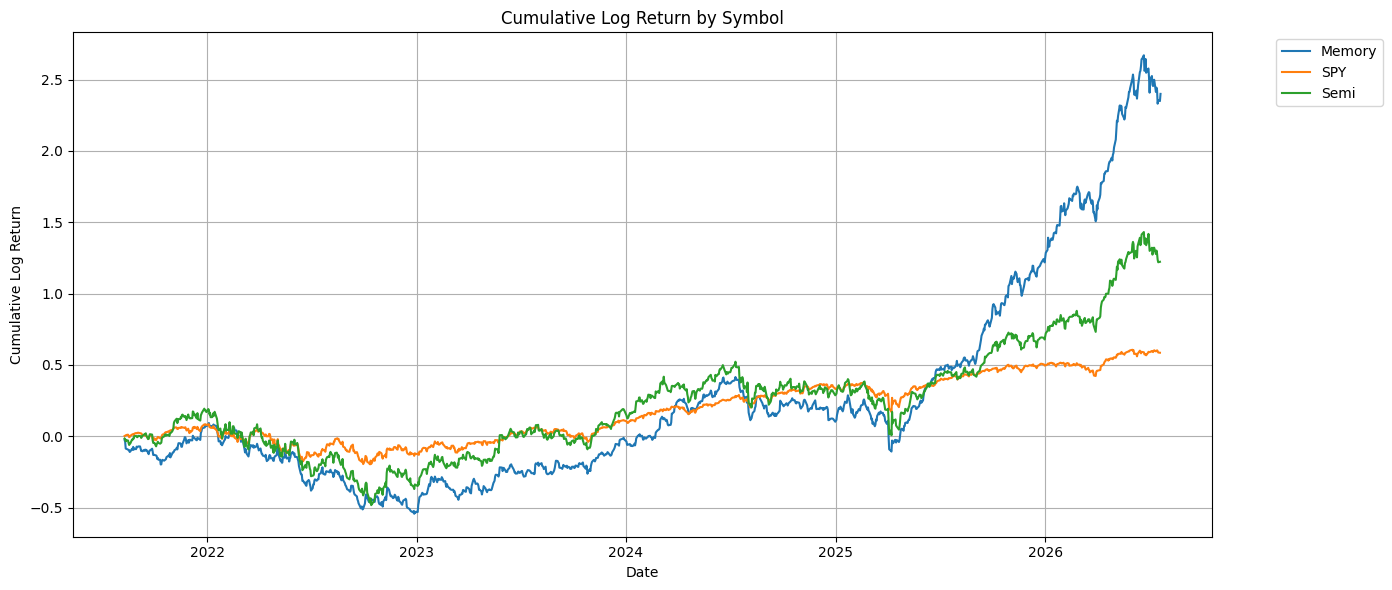

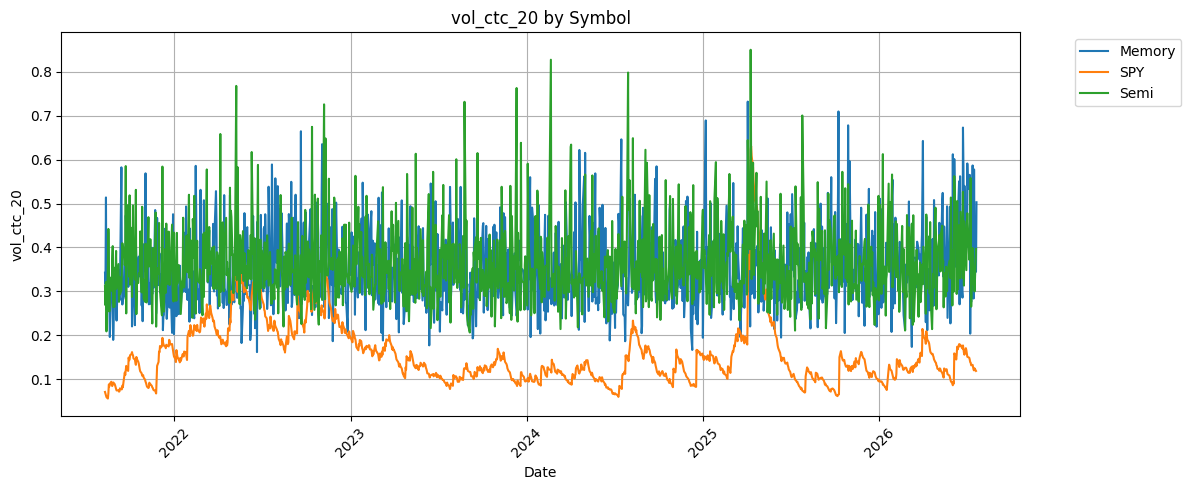

Spy


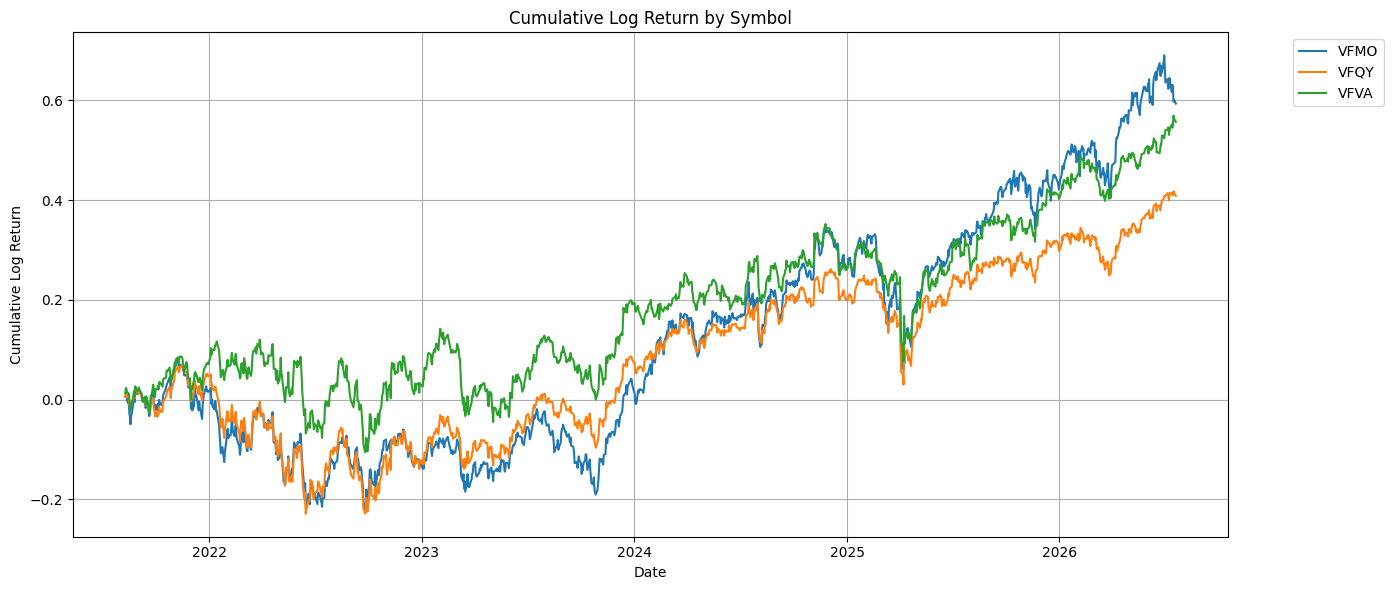

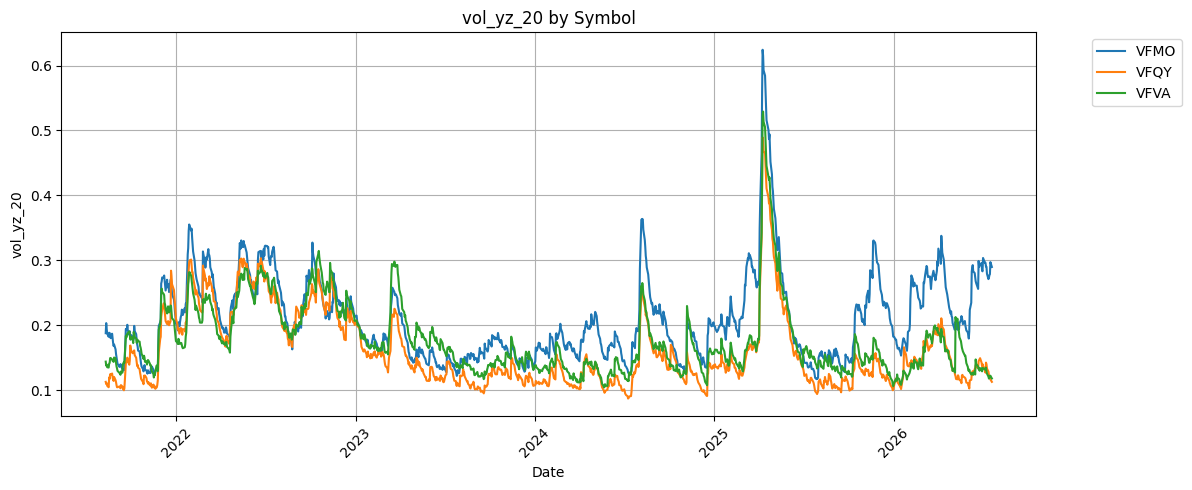

Semi


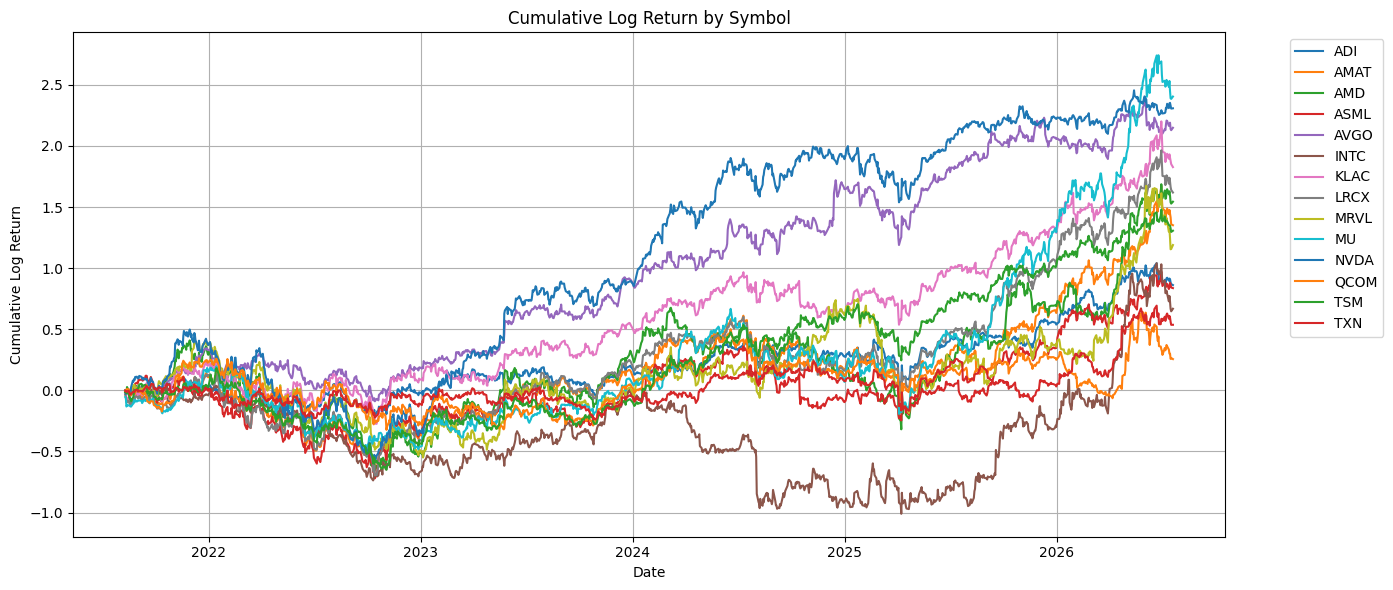

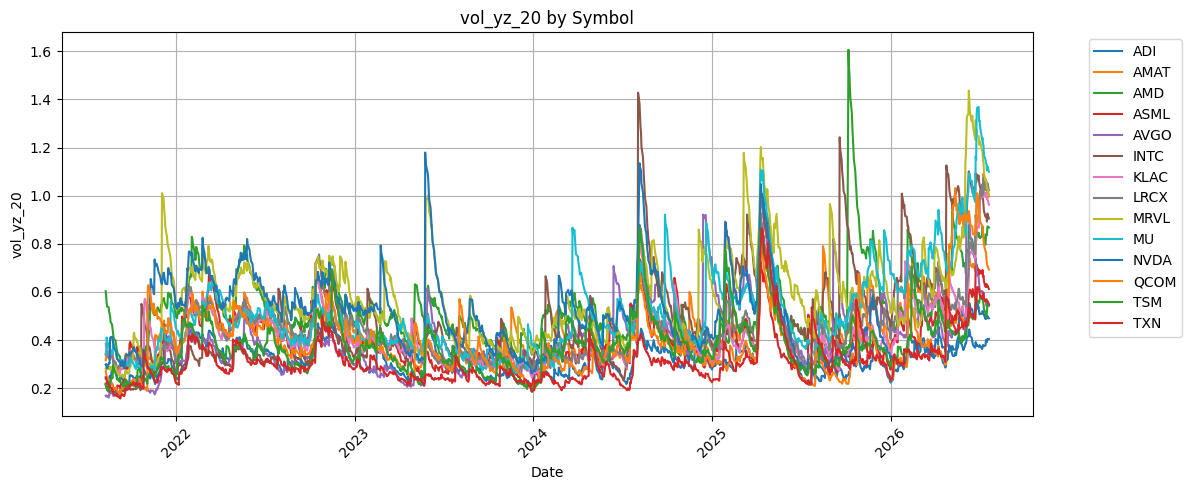

Memory


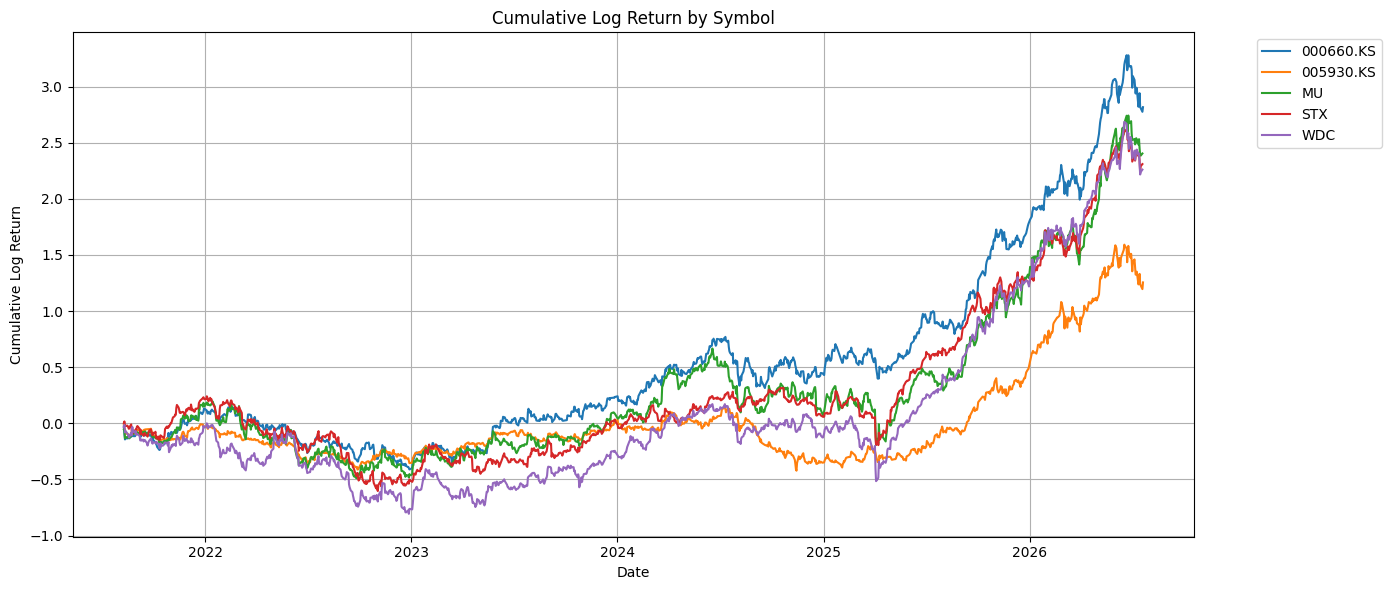

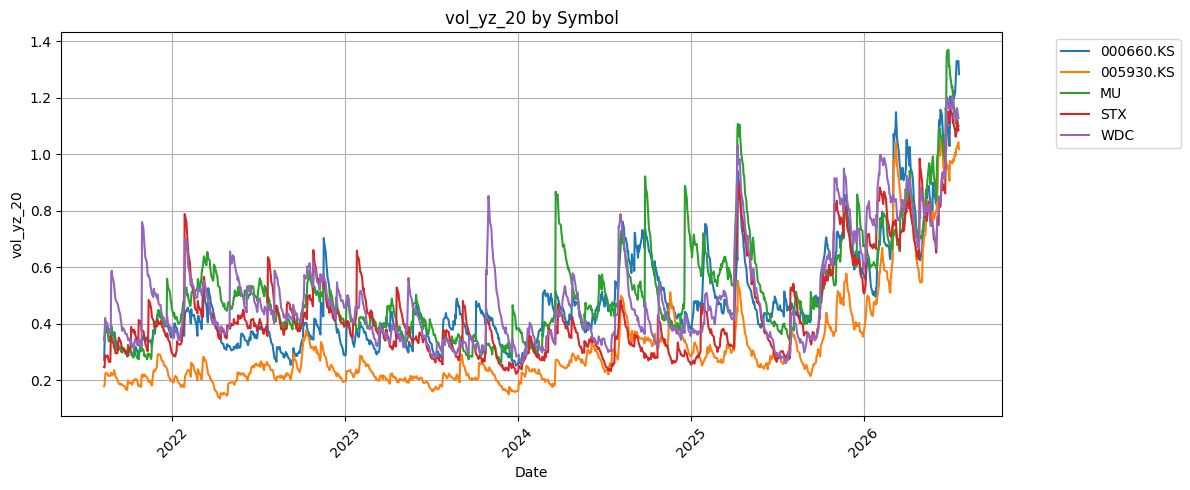

In [354]:
def plot_symbols(df, col="close"):
    dff = (
        df
        .select(["date", "symbol", col])
        .sort(["symbol", "date"])
    )

    pdf = dff.to_pandas()

    mean_df = (
        pdf
        .groupby("date")[col]
        .mean()
        .reset_index()
    )

    plt.figure(figsize=(12, 5))

    for symbol, group in pdf.groupby("symbol"):
        plt.plot(
            group["date"],
            group[col],
            label=symbol
        )

    """
    plt.plot(
        mean_df["date"],
        mean_df[col],
        label="Mean",
        linewidth=3
    )
    """

    plt.title(f"{col} by Symbol")
    plt.xlabel("Date")
    plt.ylabel(col)
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.legend(
        bbox_to_anchor=(1.05, 1),
        loc="upper left"
    )
    plt.tight_layout()
    plt.show()


def plot_all_cumulative_log_ret(df):
    data = (
        df
        .sort(["symbol", "date"])
        .with_columns(
            pl.col("log_ret")
            .cum_sum()
            .over("symbol")
            .alias("cum_log_ret")
        )
    )

    plot_df = data.select(
        ["date", "symbol", "cum_log_ret"]
    ).to_pandas()

    mean_df = (
        plot_df
        .groupby("date")["cum_log_ret"]
        .mean()
        .reset_index()
    )

    plt.figure(figsize=(14, 6))

    for symbol, group in plot_df.groupby("symbol"):
        plt.plot(
            group["date"],
            group["cum_log_ret"],
            label=symbol
        )

    """
    plt.plot(
        mean_df["date"],
        mean_df["cum_log_ret"],
        label="Mean",
        linewidth=3
    )
    """

    plt.title("Cumulative Log Return by Symbol")
    plt.xlabel("Date")
    plt.ylabel("Cumulative Log Return")
    plt.legend(
        bbox_to_anchor=(1.05, 1),
        loc="upper left"
    )
    plt.grid(True)
    plt.tight_layout()
    plt.show()


plot_all_cumulative_log_ret(bnch)
plot_symbols(bnch, "vol_ctc_20")

for k, v in all_symbols.items():
  print(k.title())
  ph = df.filter(pl.col("symbol").is_in(v))
  plot_all_cumulative_log_ret(ph)
  plot_symbols(ph, "vol_yz_20")

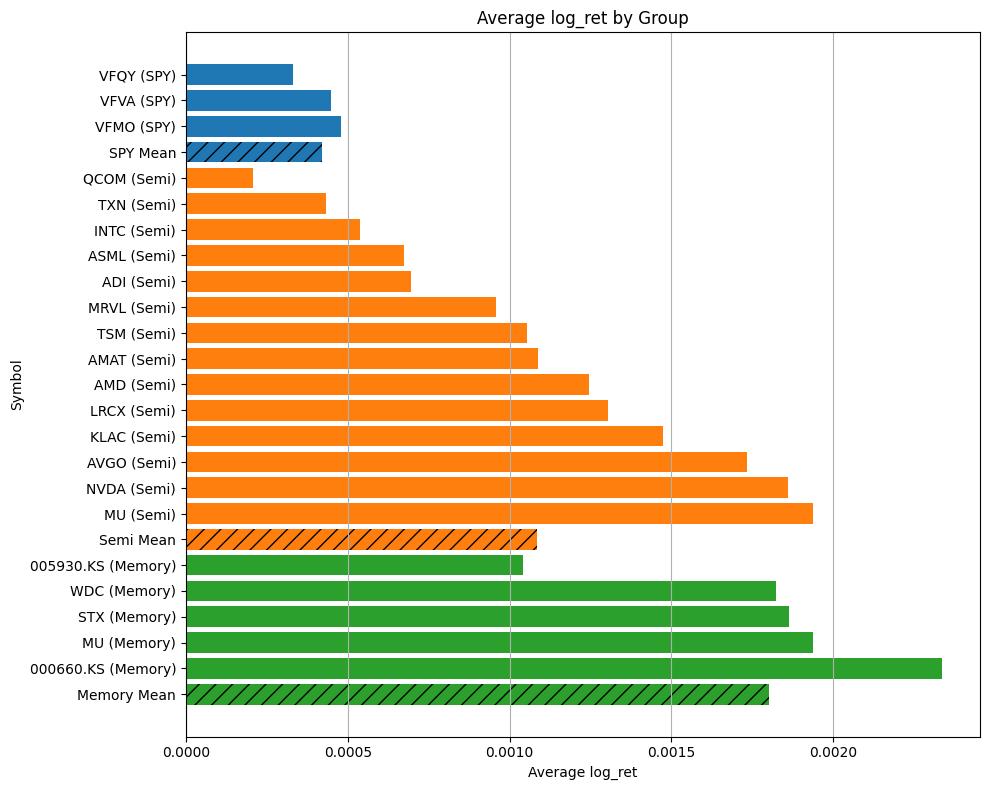

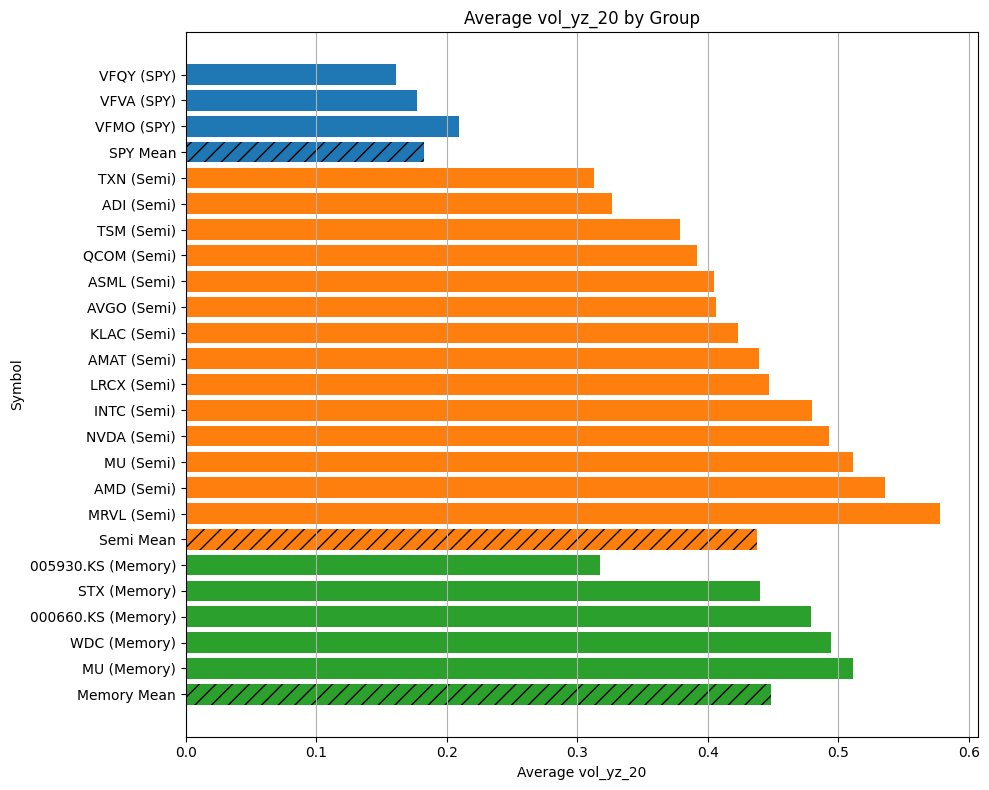

In [355]:
def plot_avg_by_group(df, col, groups):
    rows = []

    for group, symbols in groups.items():
        temp = (
            df
            .filter(pl.col("symbol").is_in(symbols))
            .group_by("symbol")
            .agg(
                pl.col(col).mean().alias("avg")
            )
            .with_columns(
                pl.lit(group).alias("group")
            )
            .sort("avg")
        )

        # symbols first
        for row in temp.iter_rows(named=True):
            rows.append({
                "label": f"{row['symbol']} ({group})",
                "avg": row["avg"],
                "group": group,
                "is_mean": False
            })

        # mean last
        rows.append({
            "label": f"{group} Mean",
            "avg": temp["avg"].mean(),
            "group": group,
            "is_mean": True
        })

    plot_df = pl.DataFrame(rows).to_pandas()

    # reverse because matplotlib barh draws first item at bottom
    plot_df = plot_df.iloc[::-1]

    group_colors = {
        group: plt.cm.tab10(i)
        for i, group in enumerate(groups.keys())
    }

    colors = [
        group_colors[g]
        for g in plot_df["group"]
    ]

    plt.figure(figsize=(10, 8))

    bars = plt.barh(
        plot_df["label"],
        plot_df["avg"],
        color=colors
    )

    # hatch mean bars
    for bar, is_mean in zip(bars, plot_df["is_mean"]):
        if is_mean:
            bar.set_hatch("//")

    plt.title(f"Average {col} by Group")
    plt.xlabel(f"Average {col}")
    plt.ylabel("Symbol")
    plt.grid(axis="x")

    plt.tight_layout()
    plt.show()


plot_avg_by_group(df, "log_ret", all_symbols)
plot_avg_by_group(df, "vol_yz_20", all_symbols)

Spy


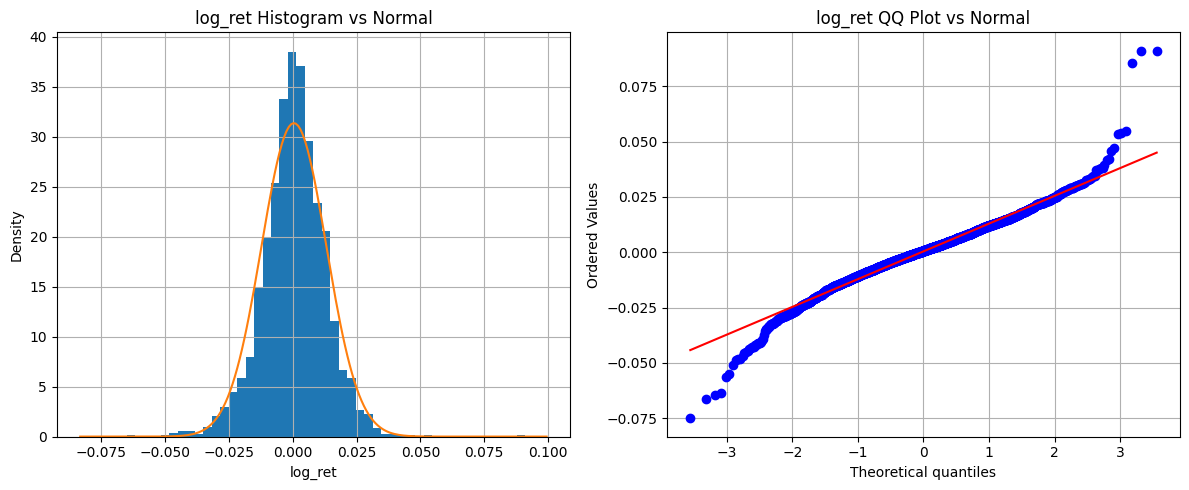

Semi


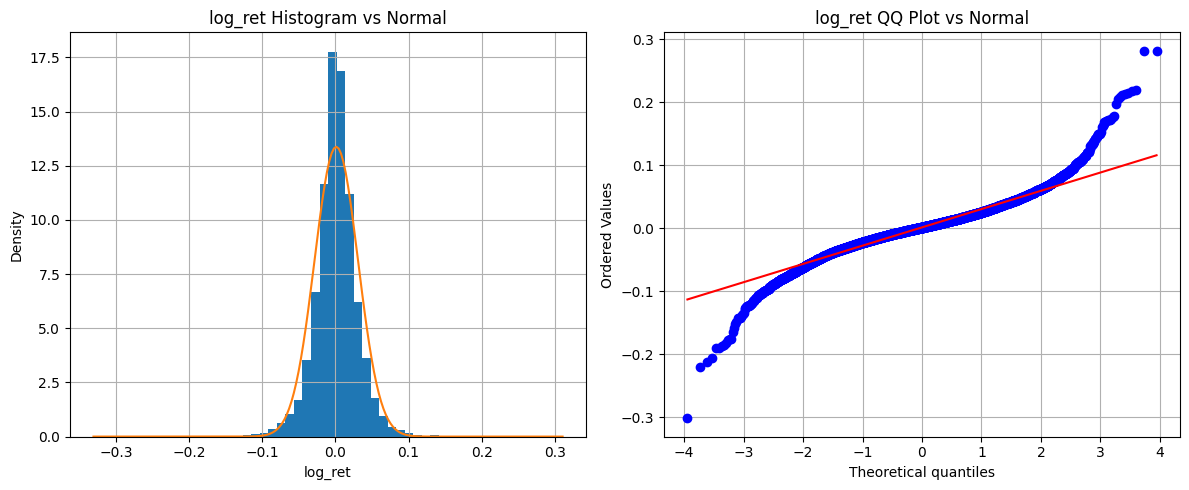

Memory


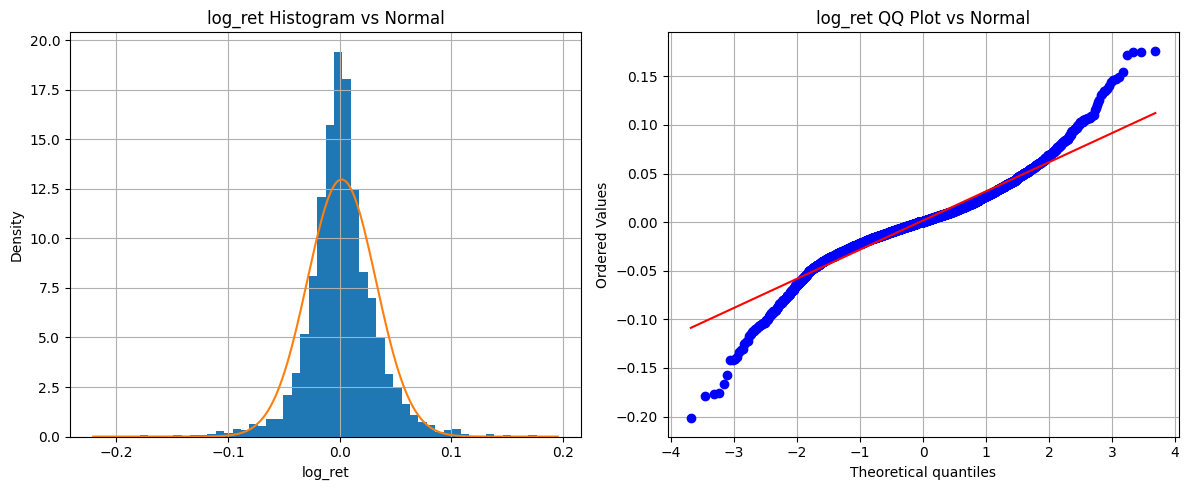

In [367]:
def plot_hist_qq(df, col="log_ret", bins=50):
    x = (
        df
        .select(col)
        .drop_nulls()
        .to_series()
        .to_numpy()
    )

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Histogram
    axes[0].hist(
        x,
        bins=bins,
        density=True
    )

    # normal fit
    mu = x.mean()
    sigma = x.std()

    xmin, xmax = axes[0].get_xlim()
    xs = __import__("numpy").linspace(xmin, xmax, 200)

    normal = stats.norm.pdf(xs, mu, sigma)

    axes[0].plot(
        xs,
        normal
    )

    axes[0].set_title(f"{col} Histogram vs Normal")
    axes[0].set_xlabel(col)
    axes[0].set_ylabel("Density")
    axes[0].grid(True)

    # QQ plot
    stats.probplot(
        x,
        dist="norm",
        plot=axes[1]
    )

    axes[1].set_title(f"{col} QQ Plot vs Normal")
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

for k, v in all_symbols.items():
  print(k.title())
  ph = df.filter(pl.col("symbol").is_in(v))
  plot_hist_qq(ph, col="log_ret")

Correlation Analysis

Spy


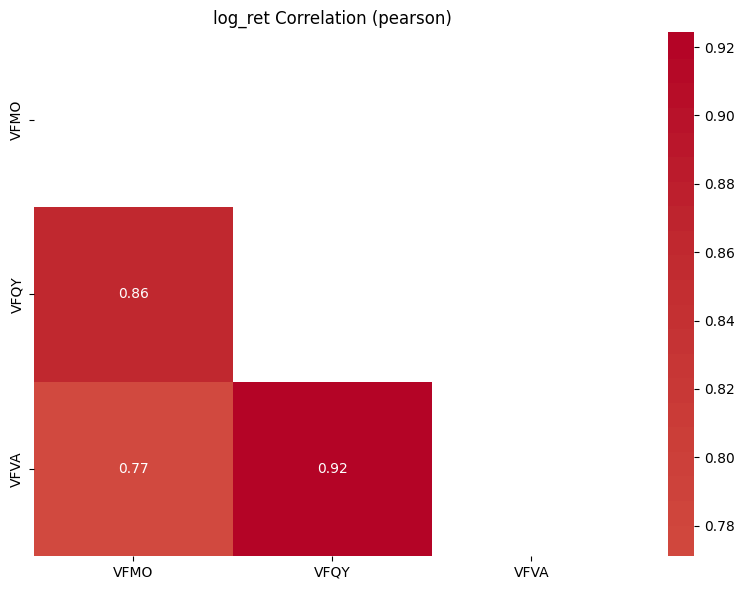

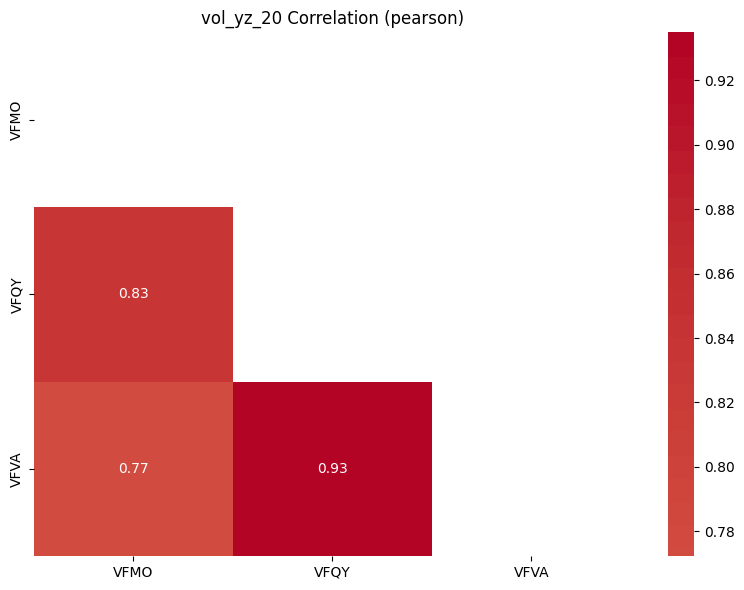

Semi


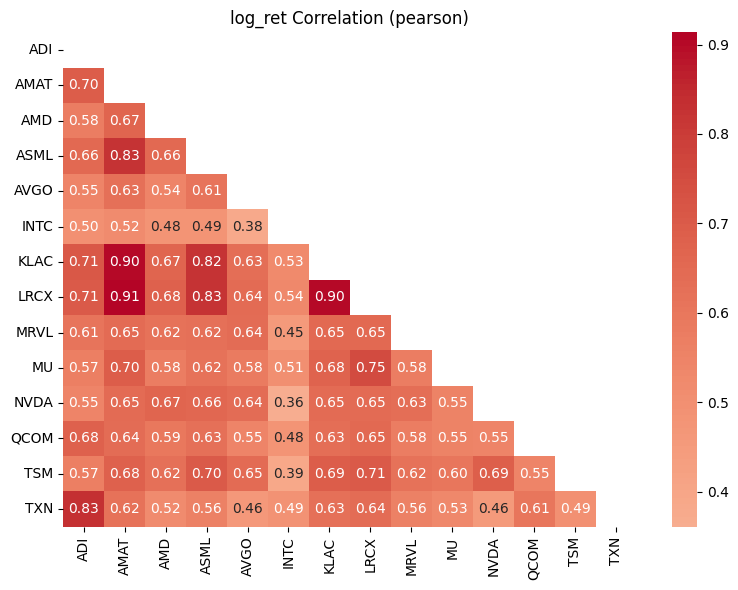

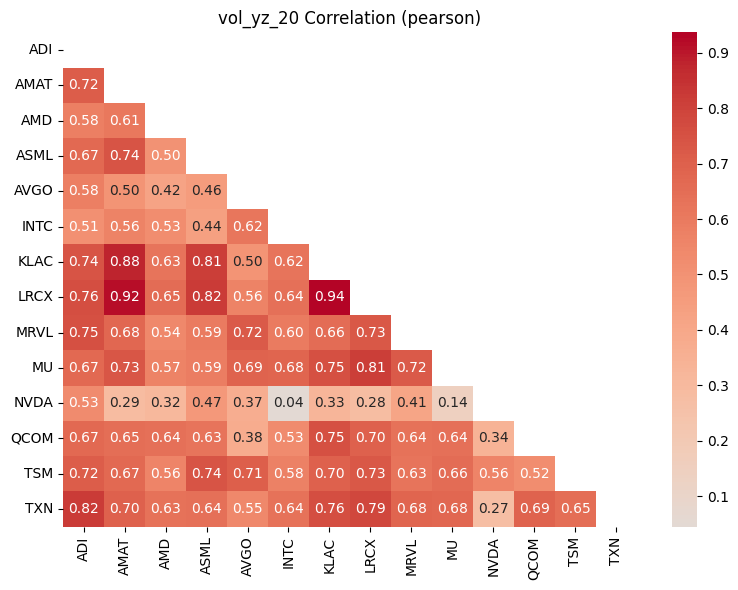

Memory


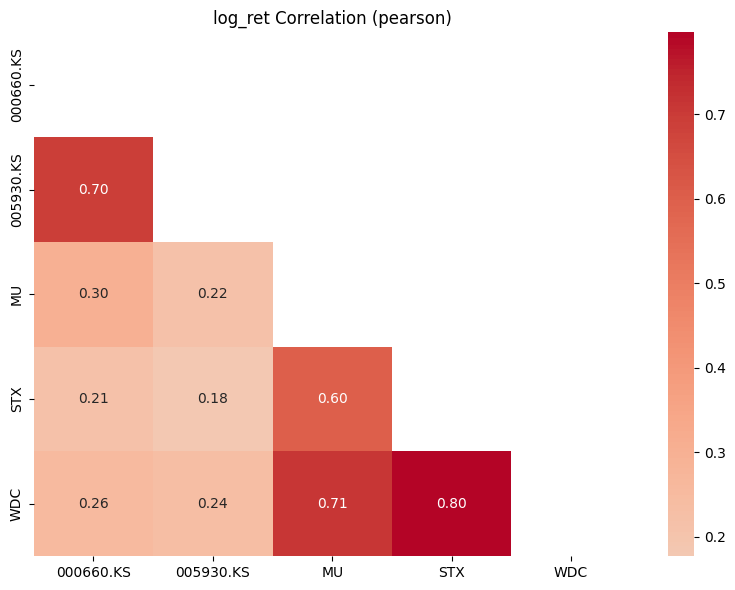

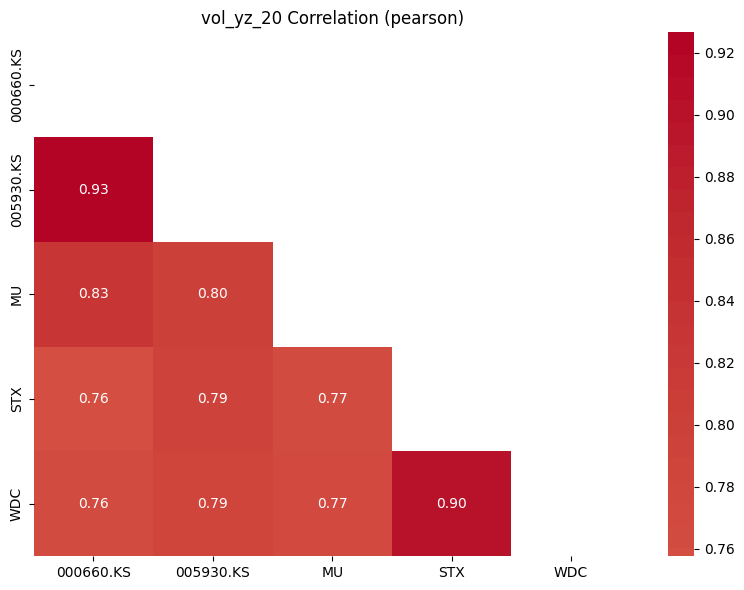

In [356]:
def plot_symbol_corr(df, col="log_ret", method="pearson"):
    wide = (
        df
        .select(["date", "symbol", col])
        .pivot(
            values=col,
            index="date",
            on="symbol"
        )
        .to_pandas()
    )

    corr = wide.drop(columns=["date"]).corr(method)
    mask = np.triu(np.ones_like(corr, dtype=bool))

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        corr,
        mask=mask,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0
    )

    plt.title(f"{col} Correlation ({method})")
    plt.tight_layout()
    plt.show()


for k in all_symbols.keys():
  print(k.title())
  ph = df.filter(pl.col("symbol").is_in(all_symbols[k]))
  plot_symbol_corr(ph, col="log_ret")
  plot_symbol_corr(ph, col="vol_yz_20")

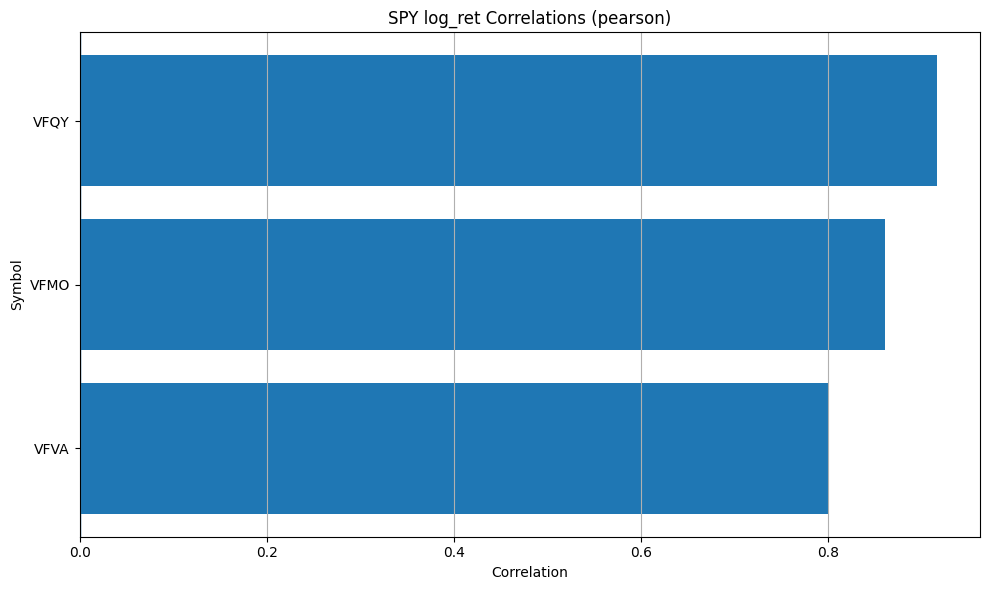

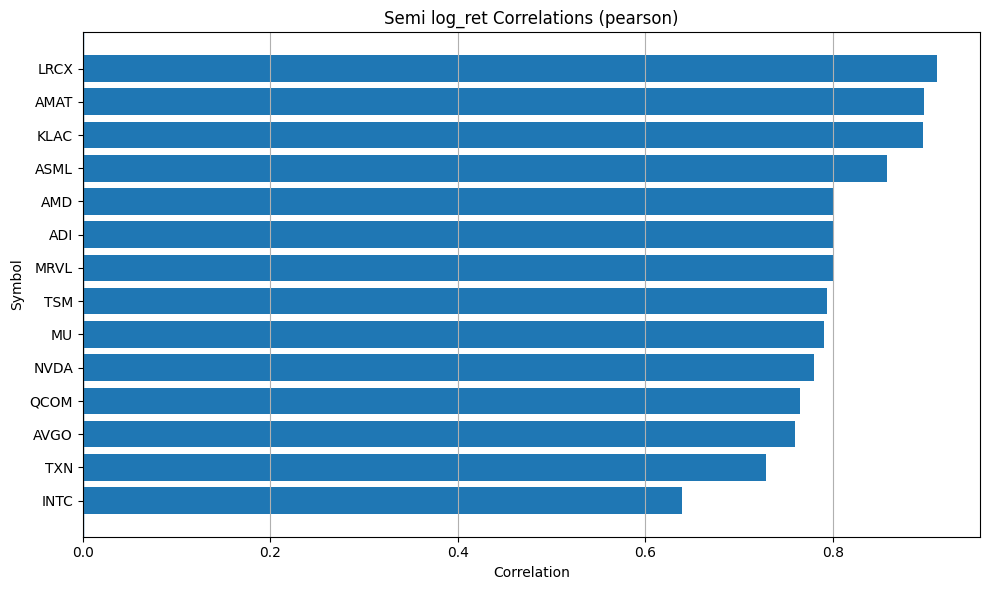

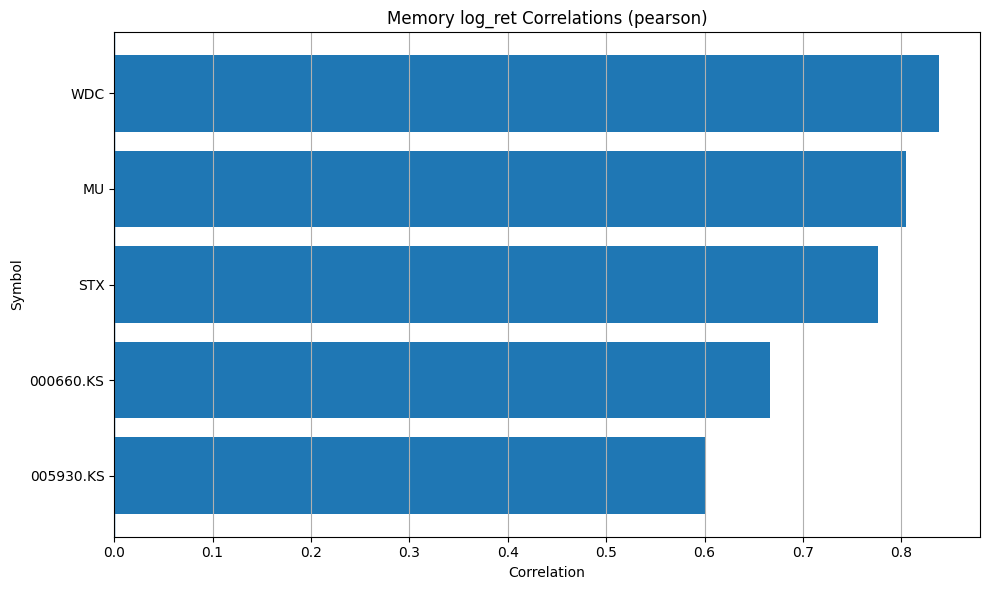

In [357]:
def plot_symbol_corr(df, symbol, col="log_ret", method="pearson"):
    wide = (
        df
        .select(["date", "symbol", col])
        .pivot(
            values=col,
            index="date",
            on="symbol"
        )
    )

    corr = (
        wide
        .to_pandas()
        .drop(columns=["date"])
        .corr(method)[symbol]
        .drop(symbol)
        .sort_values()
    )

    plt.figure(figsize=(10, 6))

    plt.barh(
        corr.index,
        corr.values
    )

    plt.axvline(0, linewidth=1)

    plt.title(f"{symbol} {col} Correlations ({method})")
    plt.xlabel("Correlation")
    plt.ylabel("Symbol")
    plt.grid(axis="x")

    plt.tight_layout()
    plt.show()


for k, v in all_symbols.items():
  ph = pl.concat([bnch.filter(pl.col("symbol")==k), df.filter(pl.col("symbol").is_in(v)).select(pl.col("date", "symbol", "log_ret", "vol_ctc_20"))])
  plot_symbol_corr(ph, k, col="log_ret")
  #plot_symbol_corr(ph, k, col="vol_ctc_20")

SPY


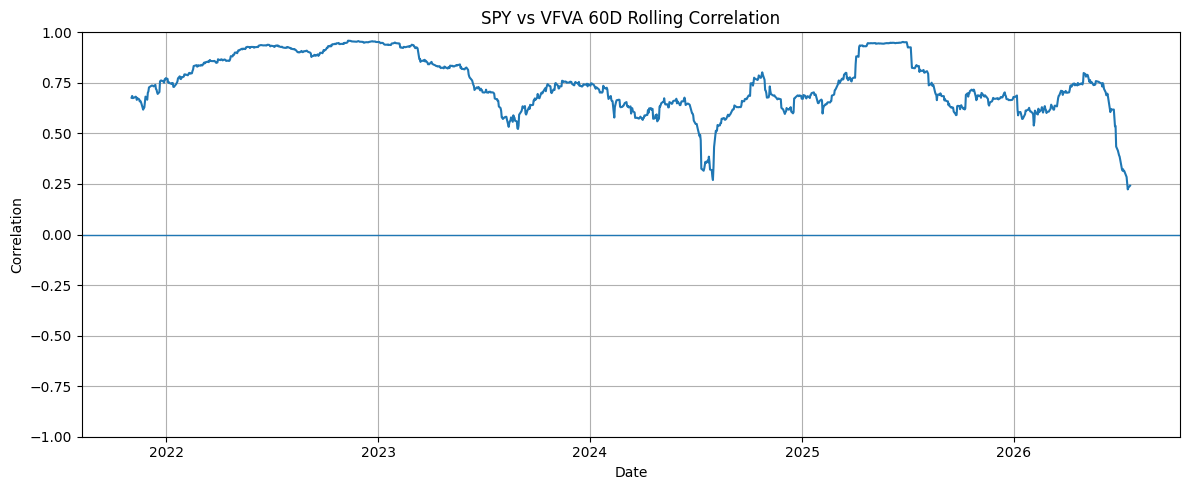

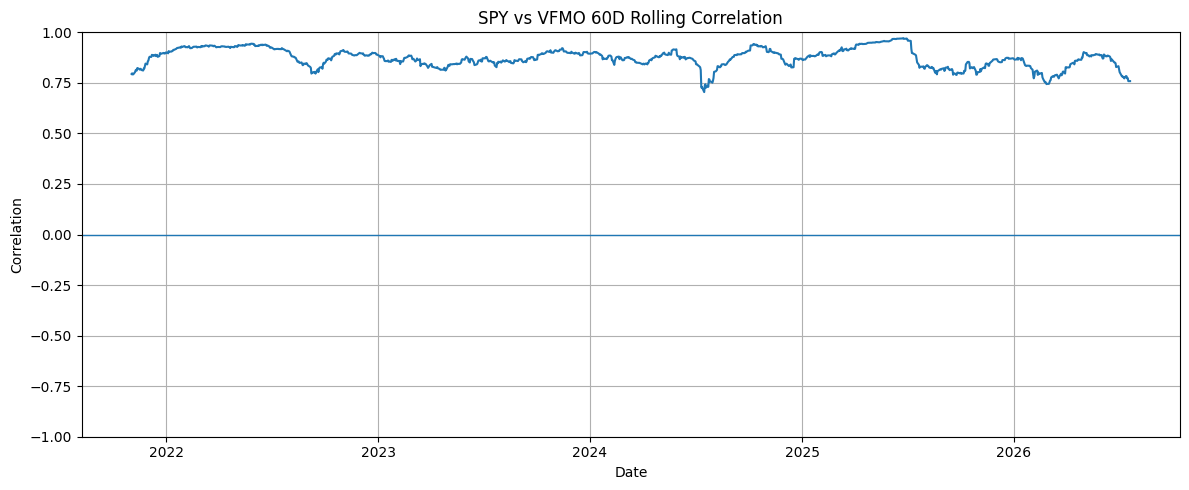

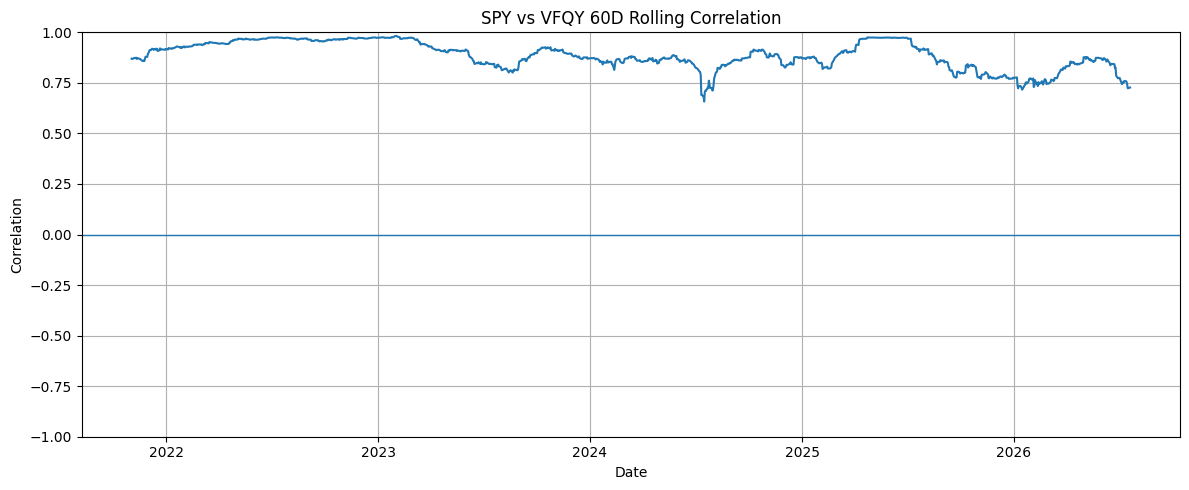

Semi


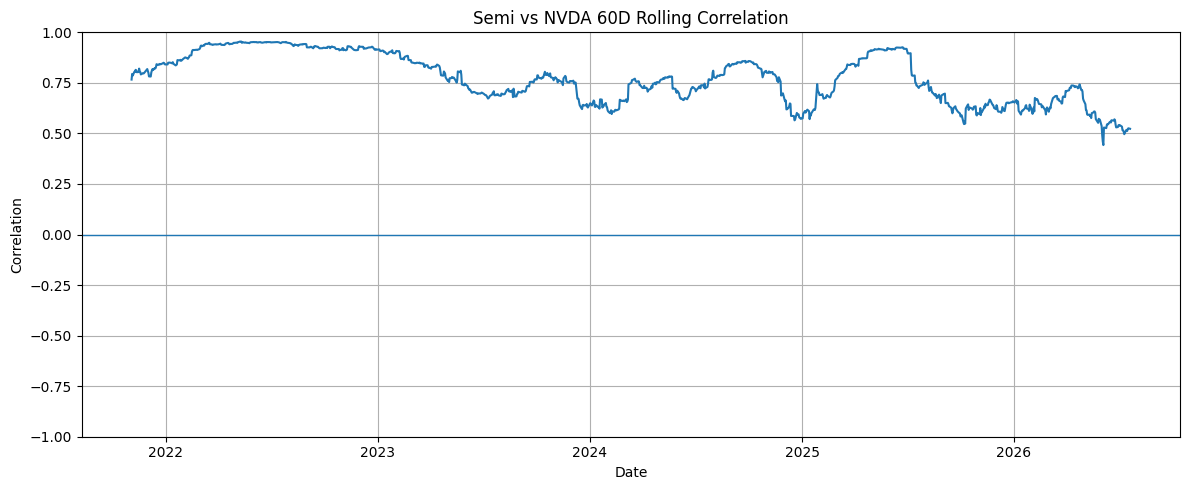

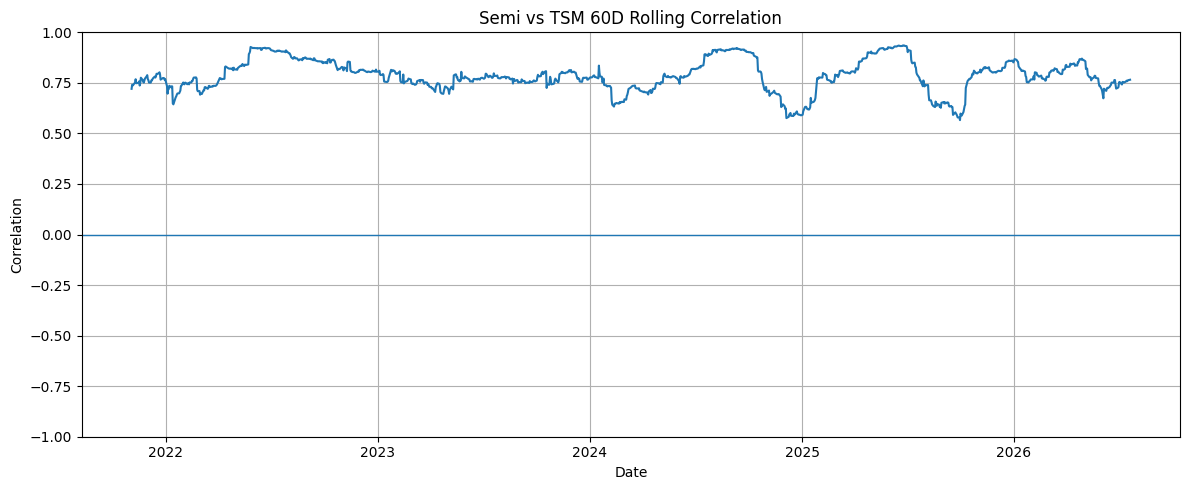

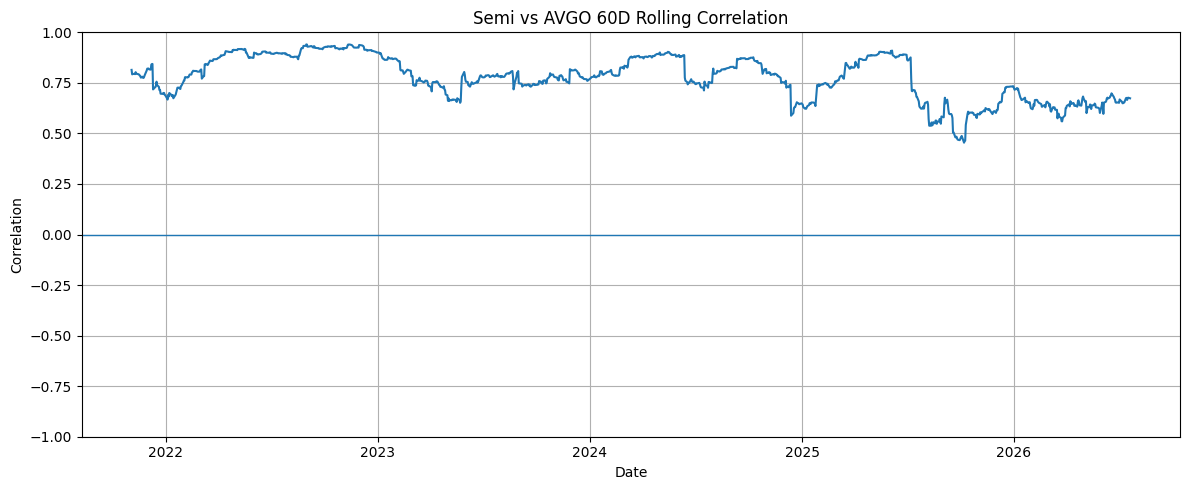

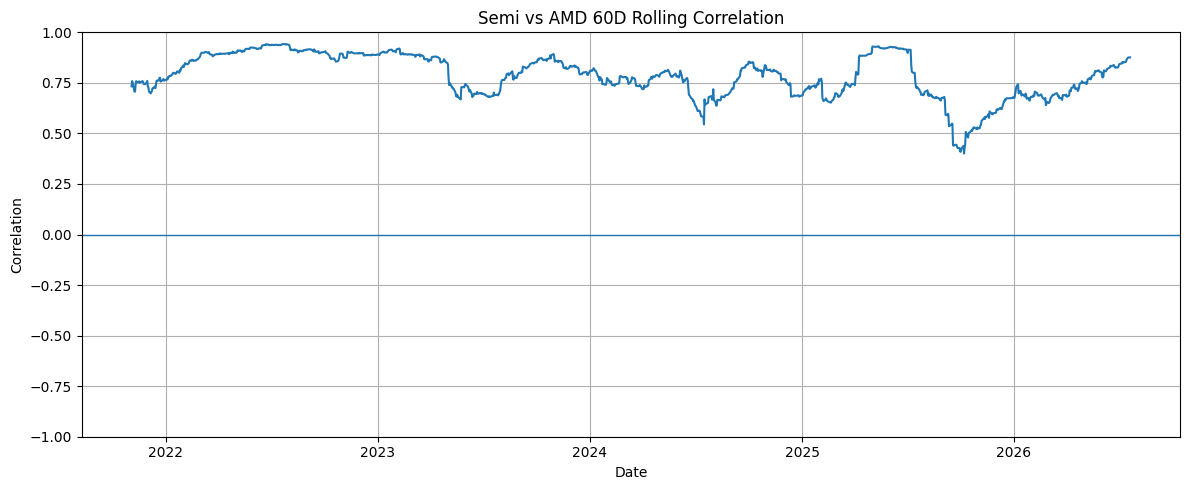

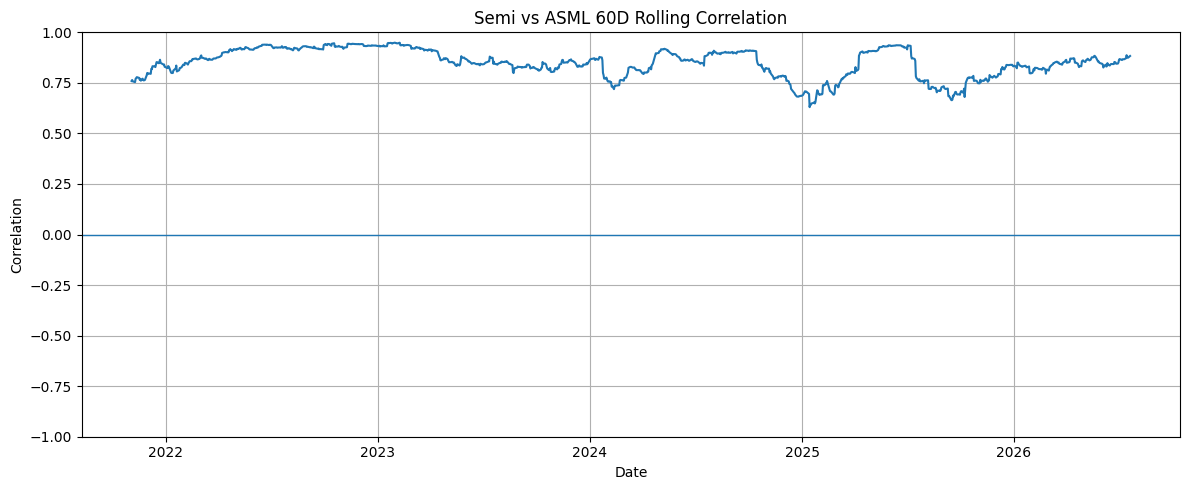

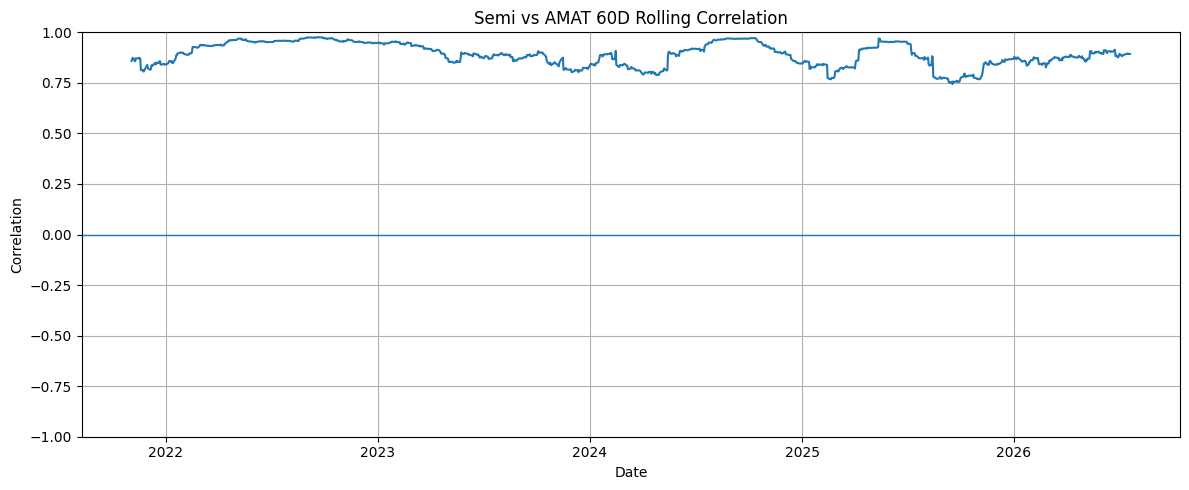

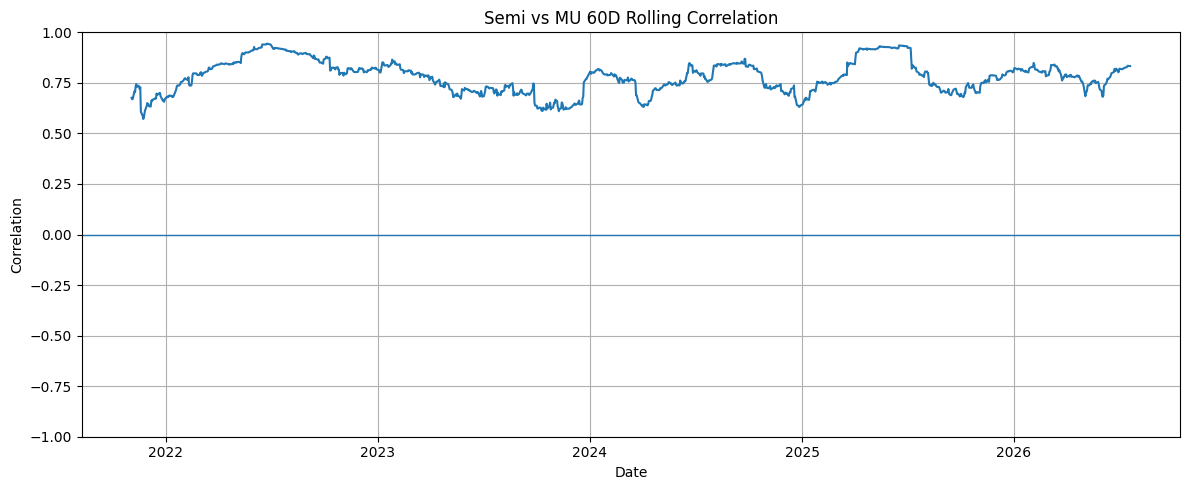

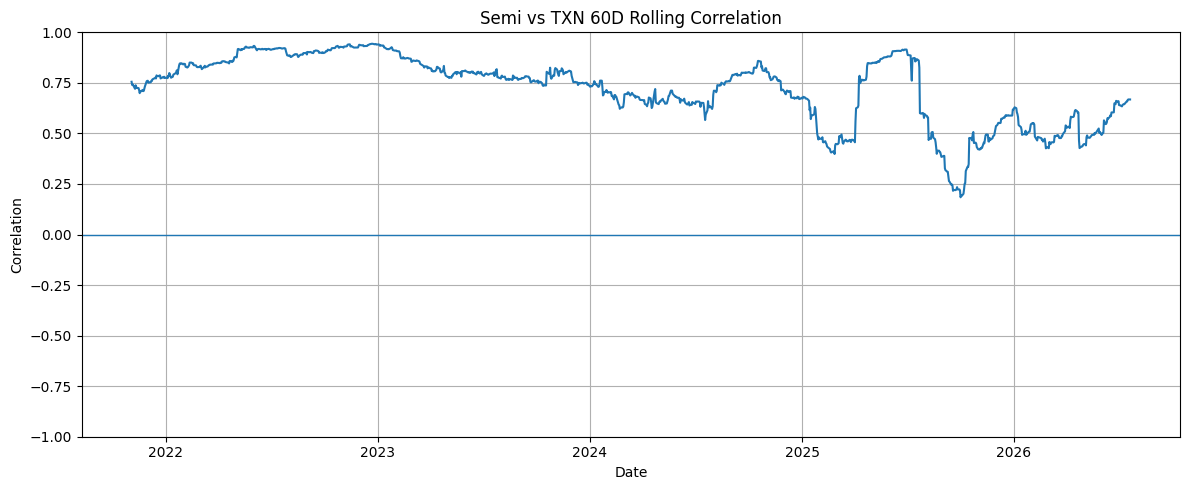

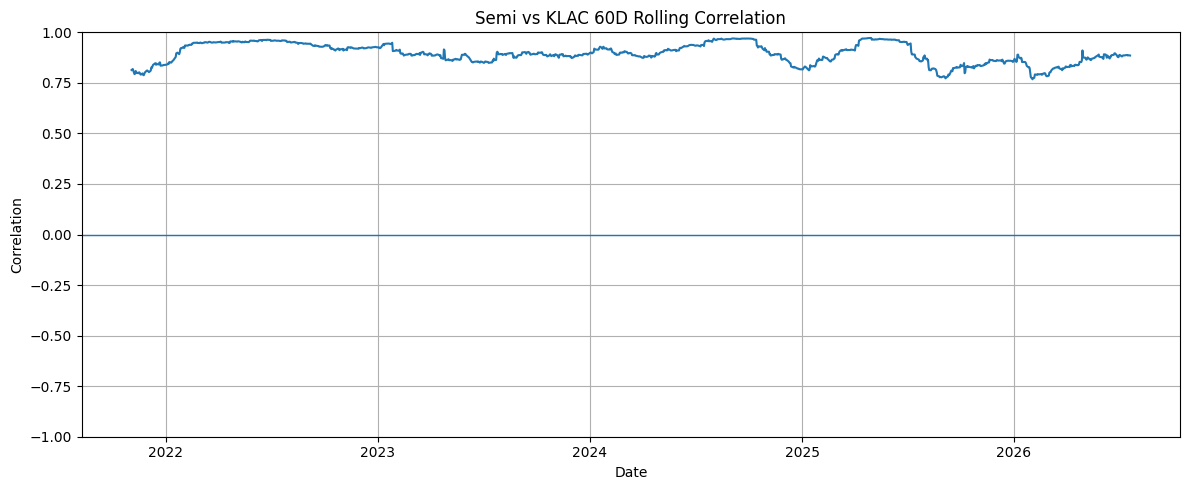

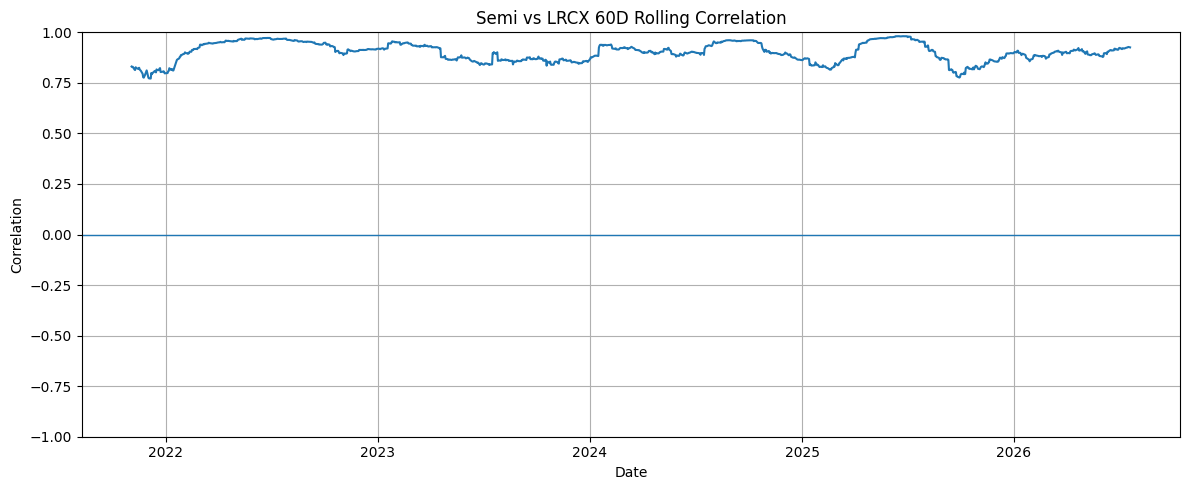

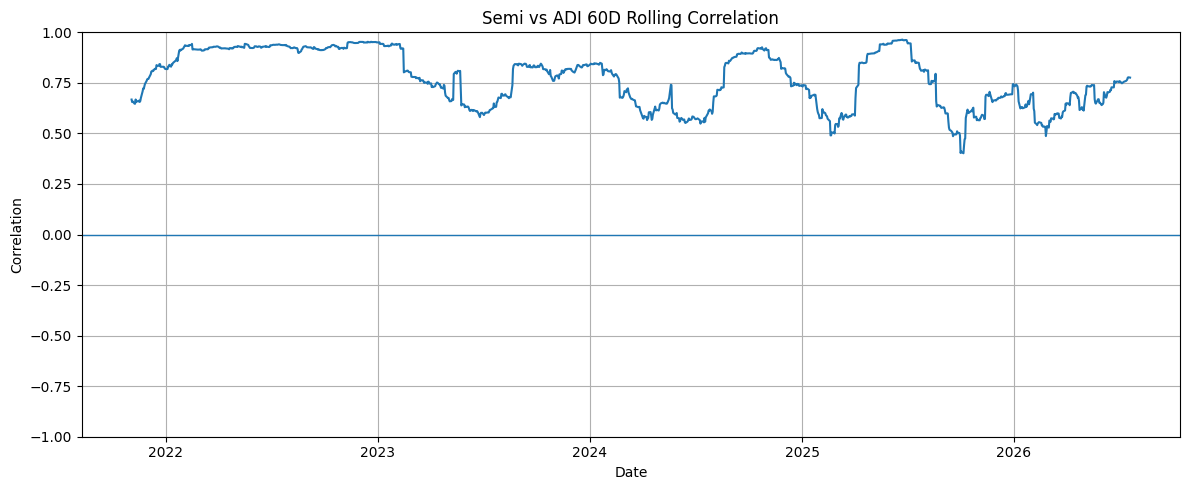

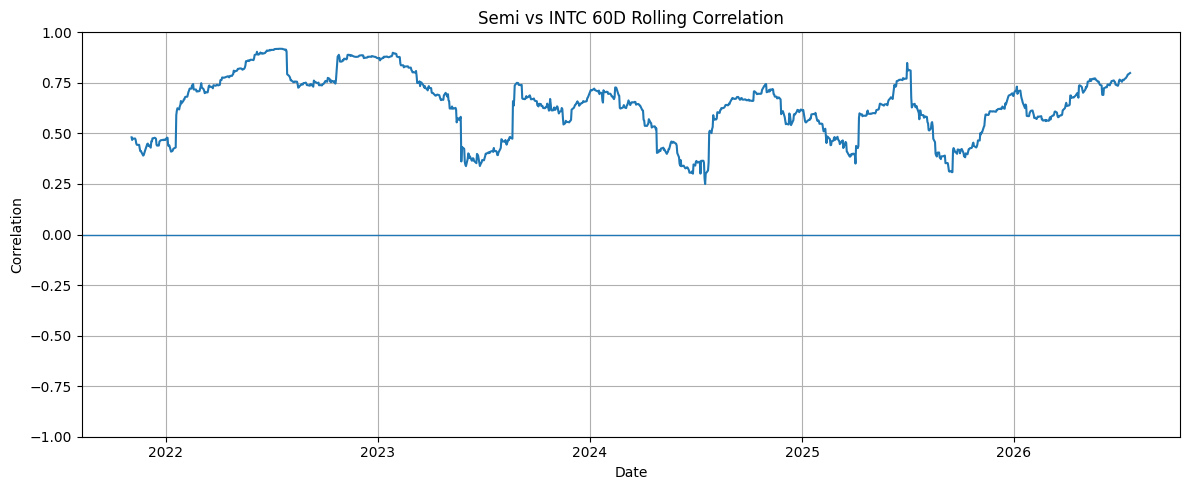

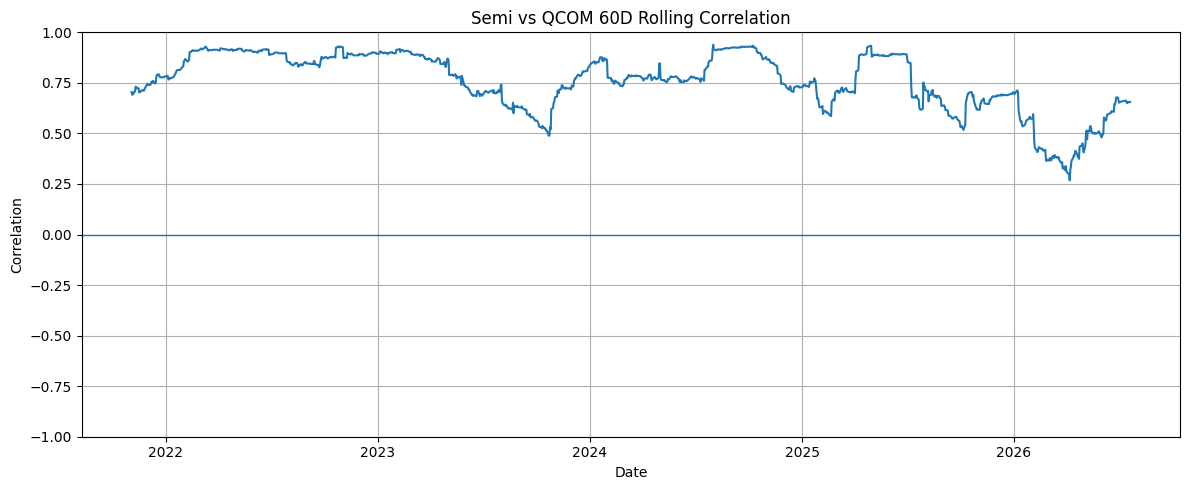

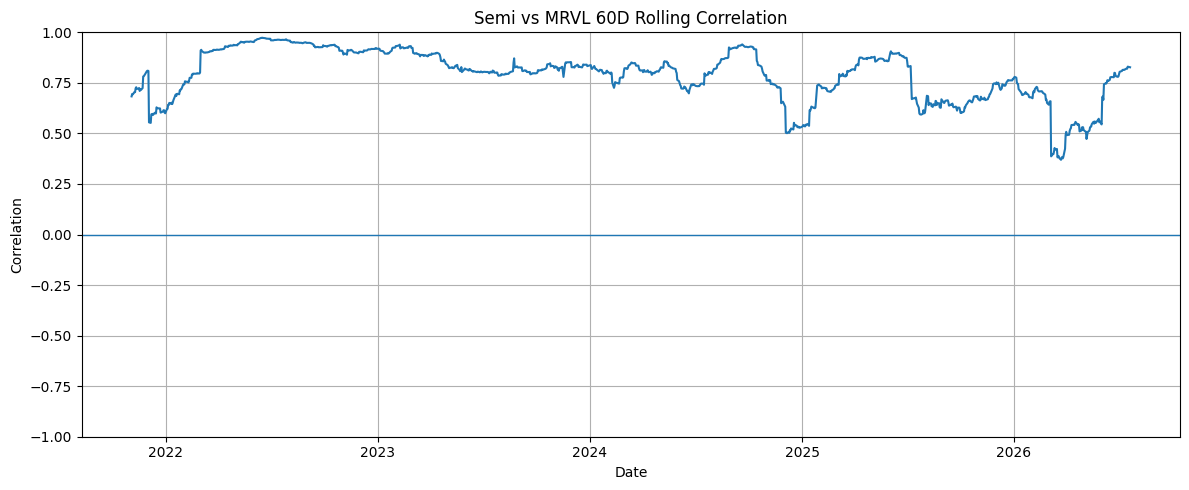

Memory


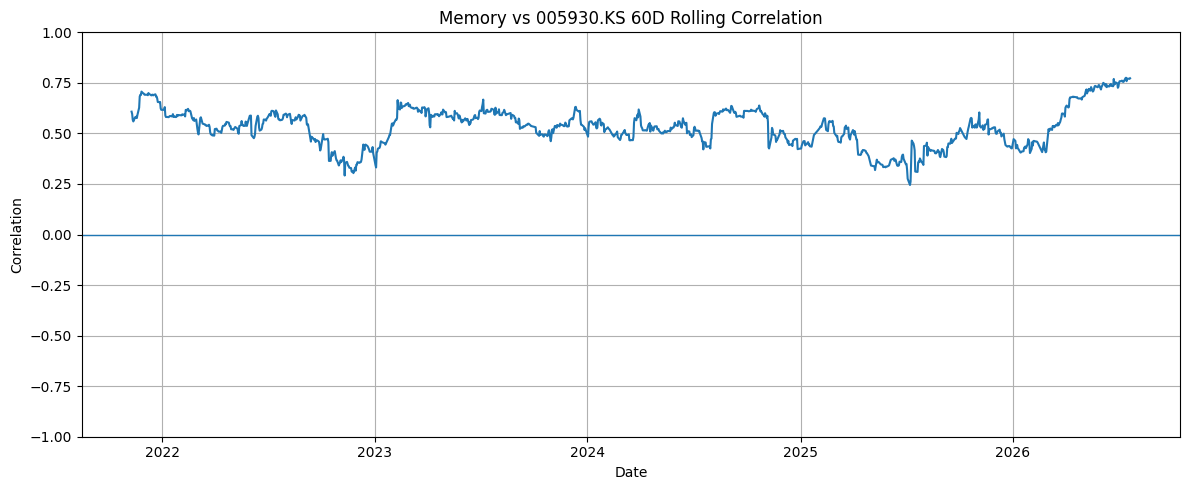

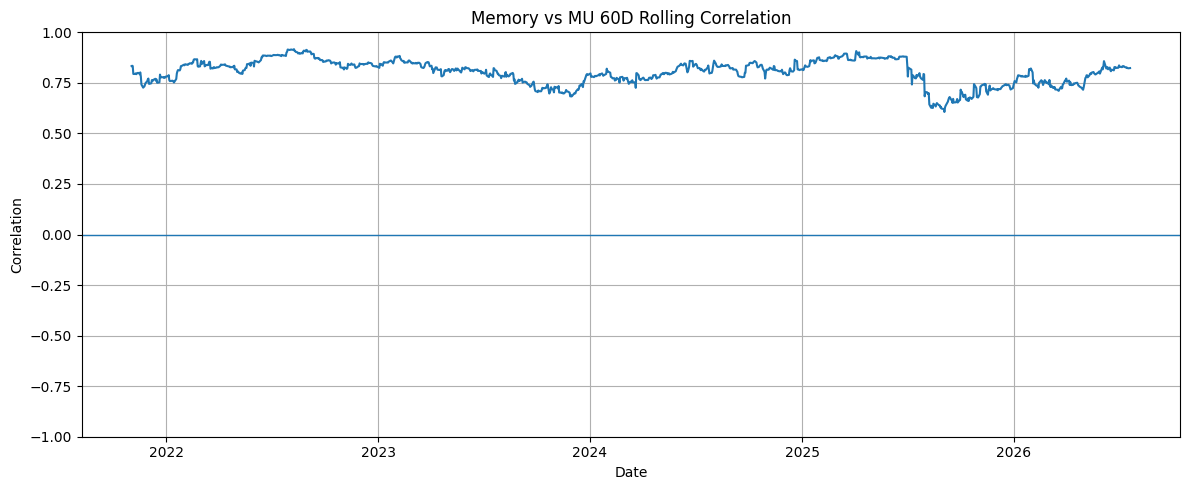

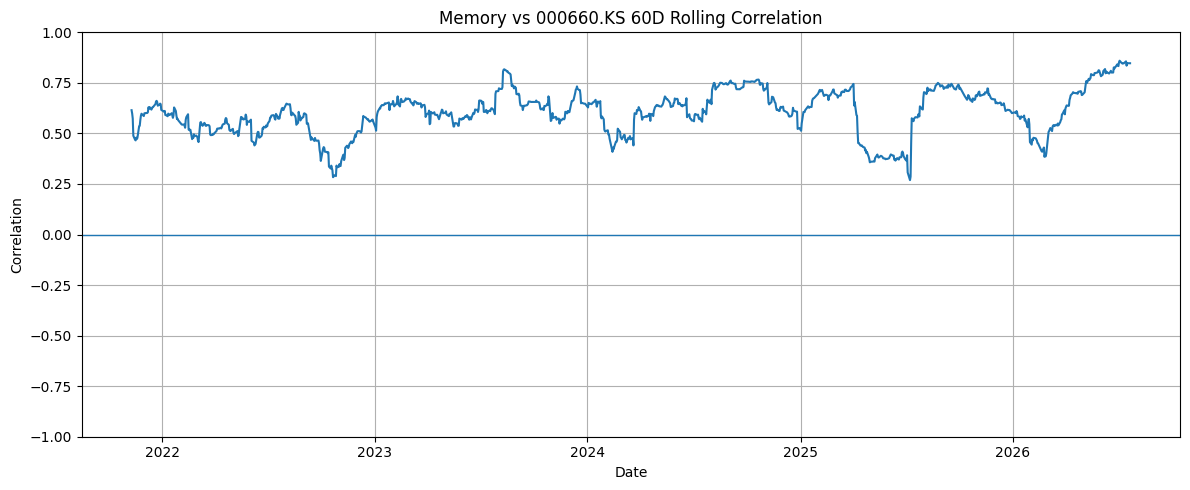

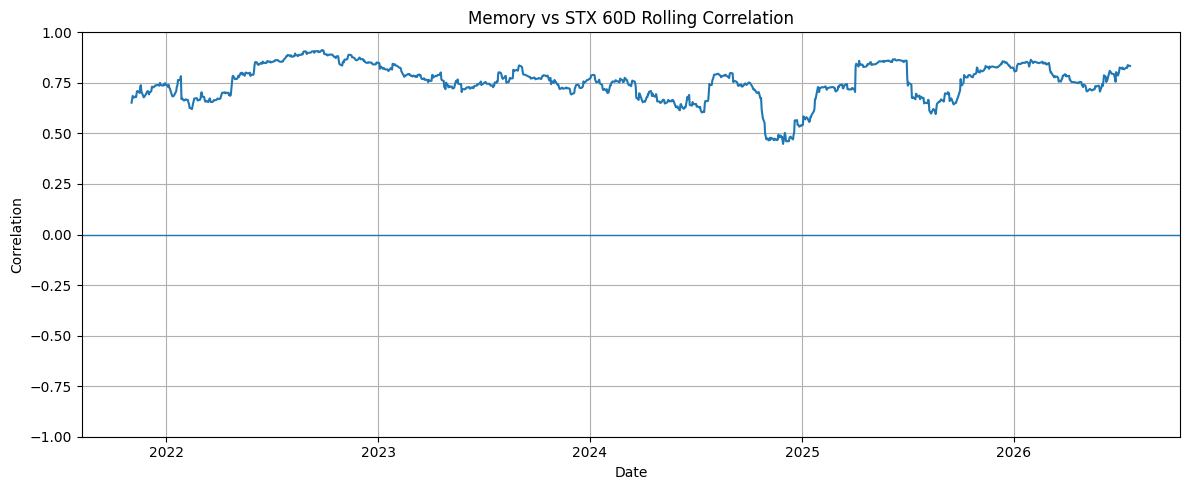

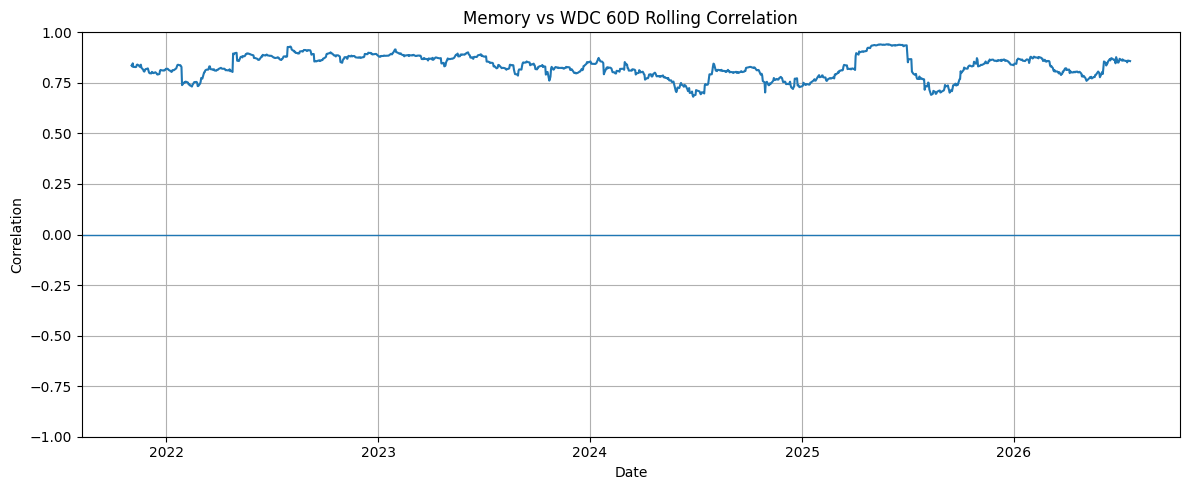

In [363]:
def plot_rolling_corr(df, sym1, sym2, col="log_ret", window=60):
    wide = (
        df
        .filter(pl.col("symbol").is_in([sym1, sym2]))
        .select(["date", "symbol", col])
        .pivot(
            values=col,
            index="date",
            on="symbol"
        )
        .drop_nulls()
        .sort("date")
    )

    corr_df = (
        wide
        .with_columns(
            pl.rolling_corr(
                pl.col(sym1),
                pl.col(sym2),
                window_size=window
            ).alias("rolling_corr")
        )
        .select(["date", "rolling_corr"])
        .drop_nulls()
        .to_pandas()
    )

    plt.figure(figsize=(12,5))

    plt.plot(
        corr_df["date"],
        corr_df["rolling_corr"]
    )

    plt.axhline(0, linewidth=1)

    plt.ylim(-1, 1)

    plt.title(f"{sym1} vs {sym2} {window}D Rolling Correlation")
    plt.xlabel("Date")
    plt.ylabel("Correlation")
    plt.grid(True)

    plt.tight_layout()
    plt.show()

#for sym in all_symbols["Factor"]:
 # if sym != "SPY": plot_rolling_corr(df, "SPY", sym, window=60)

for k, v in all_symbols.items():
  print(k)
  ph = pl.concat([bnch.filter(pl.col("symbol")==k), df.filter(pl.col("symbol").is_in(v)).select(pl.col("date", "symbol", "log_ret", "vol_ctc_20"))])
  for sym in v:
    plot_rolling_corr(ph, k, sym, window=60, col="log_ret")

redo to log_ret , vol_ctc + bench
acf, ccf
acf of ^2 (raw shock)